In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/README.md
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/new_4_004.jpg
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/new_4_007.jpg
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/blue_defect_val_009.jpg
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/blue_defect_val_010.jpg
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/new_4_011.jpg
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/blue_defect_val_017.jpg
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/blue_defect_val_020.jpg
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/blue_defect_val_019.jpg
/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect/blue_defect_val_015.jpg
/kaggle/input/datasets/p12alak/final-dataset-

In [3]:
for root, dirs, files in os.walk('/kaggle/input/'):
    if 'good' in dirs and 'defect' in dirs:
        print(f'Found train/val/test folder at: {root}')
        print(f'  subfolders: {dirs}')

Found train/val/test folder at: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val
  subfolders: ['defect', 'good']
Found train/val/test folder at: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/test
  subfolders: ['defect', 'good']
Found train/val/test folder at: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/train
  subfolders: ['defect', 'good']
Found train/val/test folder at: /kaggle/input/datasets/p12alak/webcam-clean/webcam_data
  subfolders: ['defect', 'good', 'webcam_data']
Found train/val/test folder at: /kaggle/input/datasets/p12alak/webcam-clean/webcam_data/webcam_data
  subfolders: ['defect', 'good']


Device: cuda


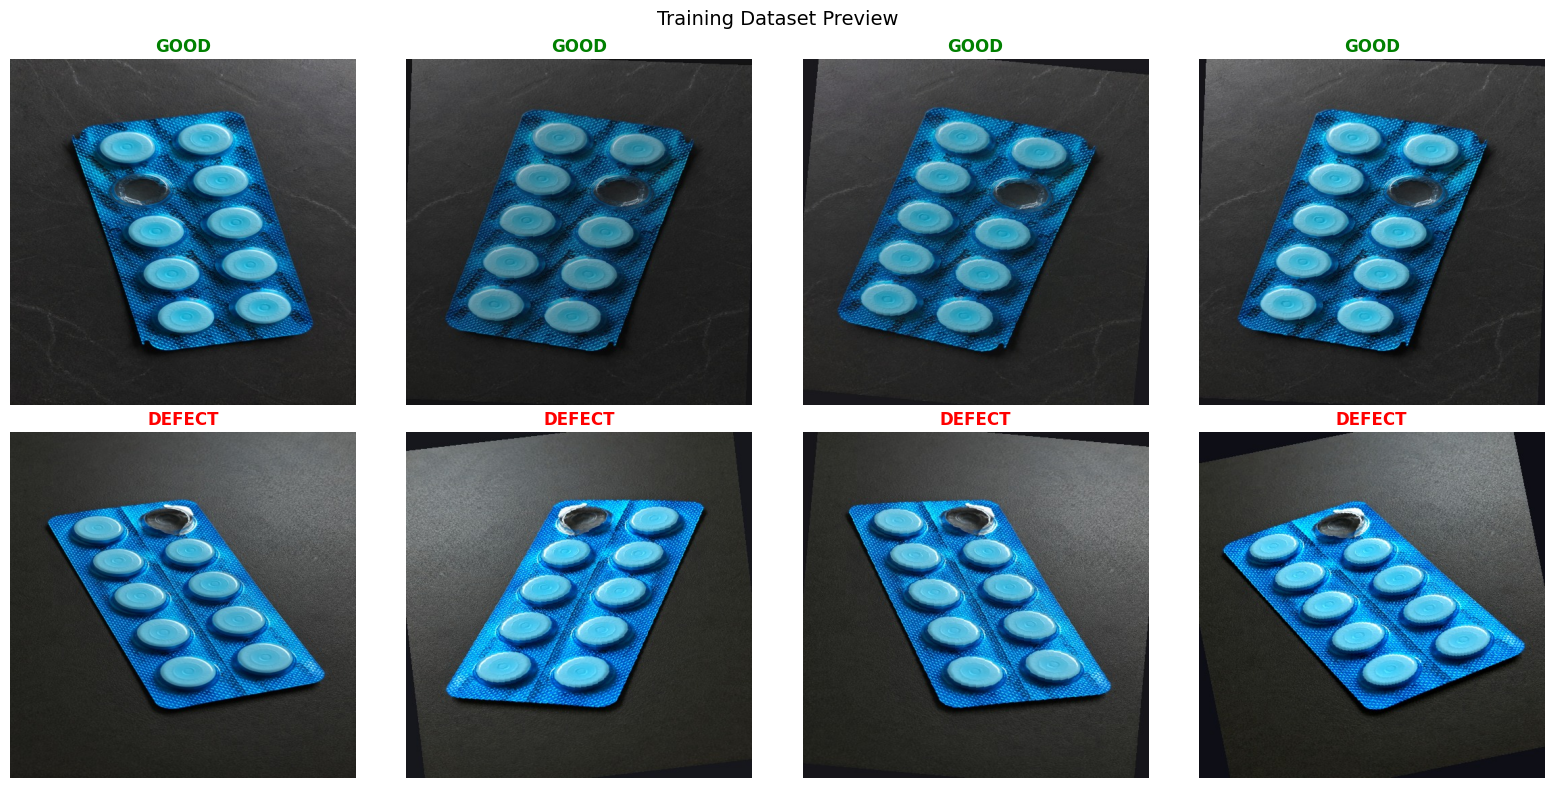

In [4]:
import os, glob
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


DATA = '/kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, name in enumerate(sorted(os.listdir(f'{DATA}/train/good'))[:4]):
    img = Image.open(f'{DATA}/train/good/{name}')
    axes[0, i].imshow(img); axes[0, i].set_title('GOOD', color='green', fontweight='bold'); axes[0, i].axis('off')
for i, name in enumerate(sorted(os.listdir(f'{DATA}/train/defect'))[:4]):
    img = Image.open(f'{DATA}/train/defect/{name}')
    axes[1, i].imshow(img); axes[1, i].set_title('DEFECT', color='red', fontweight='bold'); axes[1, i].axis('off')
plt.suptitle('Training Dataset Preview', fontsize=14)
plt.tight_layout(); plt.show()

Train: 184 good + 192 defect = 376
Valid: 77, Test: 77
Epoch  1/50 | Loss: 0.5631 | Train: 73.4% | Val: 46.8%
Epoch  2/50 | Loss: 0.2357 | Train: 91.2% | Val: 49.4%
Epoch  3/50 | Loss: 0.1479 | Train: 95.2% | Val: 50.6%
Epoch  4/50 | Loss: 0.2243 | Train: 90.4% | Val: 49.4%
Epoch  5/50 | Loss: 0.2508 | Train: 92.6% | Val: 68.8%
Epoch  6/50 | Loss: 0.1416 | Train: 94.9% | Val: 50.6%
Epoch  7/50 | Loss: 0.0921 | Train: 96.8% | Val: 49.4%
Epoch  8/50 | Loss: 0.0552 | Train: 97.9% | Val: 35.1%
Epoch  9/50 | Loss: 0.0362 | Train: 99.2% | Val: 49.4%
Epoch 10/50 | Loss: 0.0245 | Train: 99.2% | Val: 45.5%
Epoch 11/50 | Loss: 0.0308 | Train: 98.7% | Val: 46.8%
Epoch 12/50 | Loss: 0.0263 | Train: 99.7% | Val: 48.1%
Epoch 13/50 | Loss: 0.0100 | Train: 100.0% | Val: 45.5%
Epoch 14/50 | Loss: 0.0123 | Train: 99.5% | Val: 45.5%
Epoch 15/50 | Loss: 0.0076 | Train: 99.7% | Val: 41.6%
Epoch 16/50 | Loss: 0.0052 | Train: 100.0% | Val: 42.9%
Epoch 17/50 | Loss: 0.0059 | Train: 100.0% | Val: 48.1%
Epoch 1

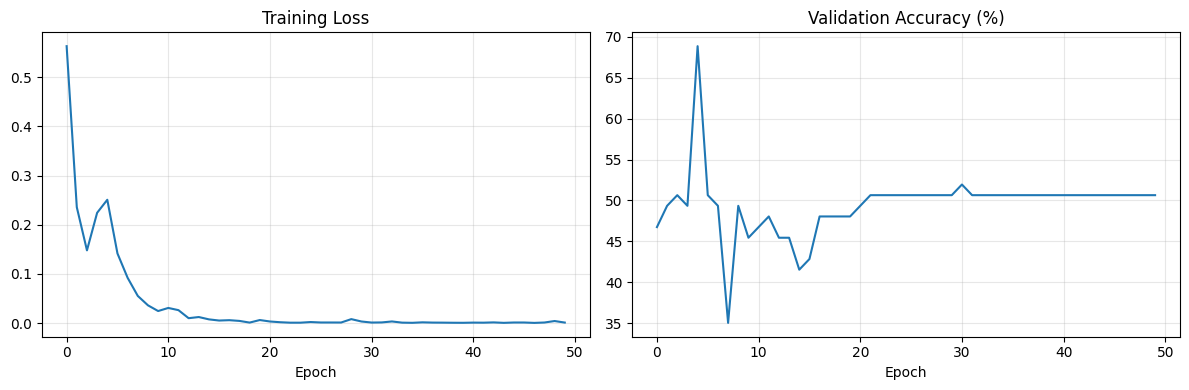

In [5]:
IMG_SIZE = 224
BATCH = 16
EPOCHS = 50

def build_samples(folder):
    samples = []
    for f in os.listdir(os.path.join(folder, 'good')):
        if f.lower().endswith(('.jpg','.jpeg','.png')):
            samples.append((os.path.join(folder, 'good', f), 0))
    for f in os.listdir(os.path.join(folder, 'defect')):
        if f.lower().endswith(('.jpg','.jpeg','.png')):
            samples.append((os.path.join(folder, 'defect', f), 1))
    return samples

train_samples = build_samples(f'{DATA}/train')
val_samples = build_samples(f'{DATA}/val')
test_samples = build_samples(f'{DATA}/test')

print(f'Train: {sum(1 for _,l in train_samples if l==0)} good + {sum(1 for _,l in train_samples if l==1)} defect = {len(train_samples)}')
print(f'Valid: {len(val_samples)}, Test: {len(test_samples)}')

# Light test-time transforms (augmentation already baked into the dataset files)
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class BlisterDS(Dataset):
    def __init__(self, samples, tf):
        self.samples = samples; self.tf = tf
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        return self.tf(Image.open(path).convert('RGB')), label

train_loader = DataLoader(BlisterDS(train_samples, train_tf), batch_size=BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(BlisterDS(val_samples, test_tf), batch_size=BATCH, num_workers=2)

model = models.resnet18(weights=None)
model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.fc.in_features, 2))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

best_val_acc = 0
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        loss_sum += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)

    model.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            vc += (model(imgs).argmax(1) == labels).sum().item()
            vt += labels.size(0)

    scheduler.step()
    val_acc = 100*vc/vt if vt else 0
    avg_loss = loss_sum/len(train_loader)
    train_losses.append(avg_loss); val_accs.append(val_acc)
    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/kaggle/working/blister_best.pth')
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | Train: {100*correct/total:.1f}% | Val: {val_acc:.1f}%')

print(f'\nBest Val Accuracy: {best_val_acc:.1f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses); ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.grid(alpha=0.3)
ax2.plot(val_accs); ax2.set_title('Validation Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/training_curves.png', dpi=150); plt.show()

TEST SET RESULTS
Average Precision: 0.8190
F1-Score:          0.7302

Confusion Matrix:
              Pred GOOD  Pred DEFECT
  True GOOD        37          0
  True DEFECT      17         23


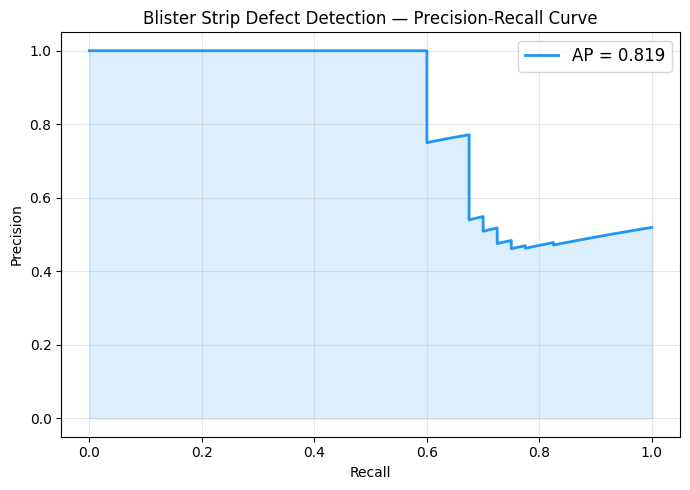

Saved: blister_pr_curve.png


In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, confusion_matrix

model.load_state_dict(torch.load('/kaggle/working/blister_best.pth', map_location=DEVICE, weights_only=True))
model.eval()

all_labels, all_probs = [], []
eval_loader = DataLoader(BlisterDS(test_samples, test_tf), batch_size=BATCH, num_workers=2)
with torch.no_grad():
    for imgs, labels in eval_loader:
        imgs = imgs.to(DEVICE)
        probs = torch.softmax(model(imgs), dim=1)[:, 1]
        all_labels.extend(labels.numpy()); all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_labels); y_score = np.array(all_probs)
precision, recall, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)
y_pred = (y_score >= 0.5).astype(int)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print('='*50)
print('TEST SET RESULTS')
print('='*50)
print(f'Average Precision: {ap:.4f}')
print(f'F1-Score:          {f1:.4f}')
print(f'\nConfusion Matrix:')
print(f'              Pred GOOD  Pred DEFECT')
print(f'  True GOOD     {cm[0][0]:5d}      {cm[0][1]:5d}')
print(f'  True DEFECT   {cm[1][0]:5d}      {cm[1][1]:5d}')

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2, color='#2196F3', label=f'AP = {ap:.3f}')
plt.fill_between(recall, precision, alpha=0.15, color='#2196F3')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Blister Strip Defect Detection — Precision-Recall Curve')
plt.legend(fontsize=12); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('/kaggle/working/blister_pr_curve.png', dpi=150); plt.show()
print('Saved: blister_pr_curve.png')

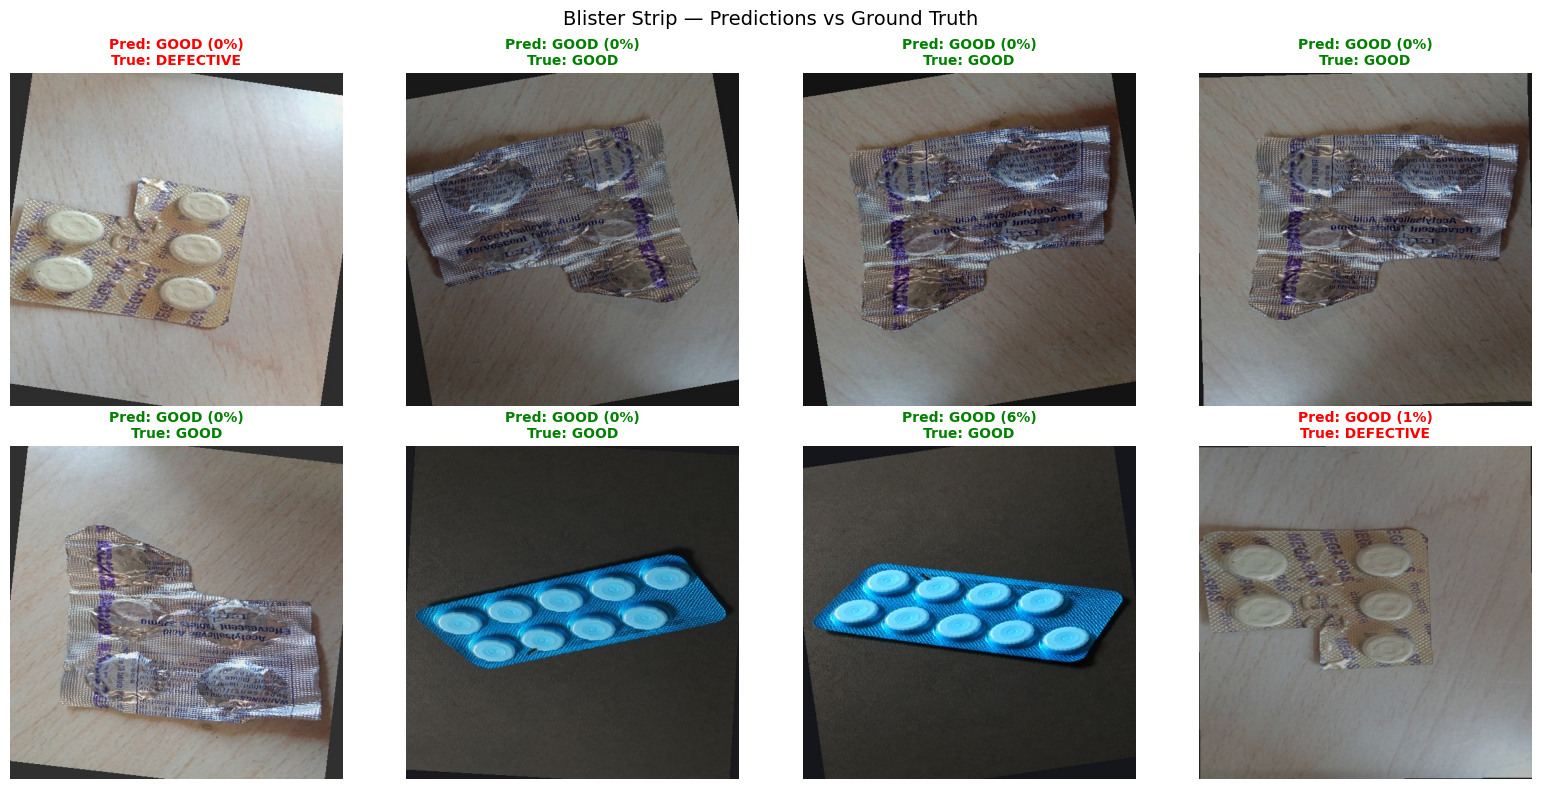

In [7]:
import random
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample = random.sample(test_samples, min(8, len(test_samples)))

for ax, (path, true_label) in zip(axes.flatten(), sample):
    img = Image.open(path).convert('RGB')
    tensor = test_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.softmax(model(tensor), dim=1)[0, 1].item()
    pred = 'DEFECTIVE' if prob > 0.5 else 'GOOD'
    true = 'DEFECTIVE' if true_label == 1 else 'GOOD'
    color = 'green' if (prob > 0.5) == (true_label == 1) else 'red'
    ax.imshow(img)
    ax.set_title(f'Pred: {pred} ({prob:.0%})\nTrue: {true}', color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Blister Strip — Predictions vs Ground Truth', fontsize=14)
plt.tight_layout(); plt.savefig('/kaggle/working/prediction_results.png', dpi=150); plt.show()

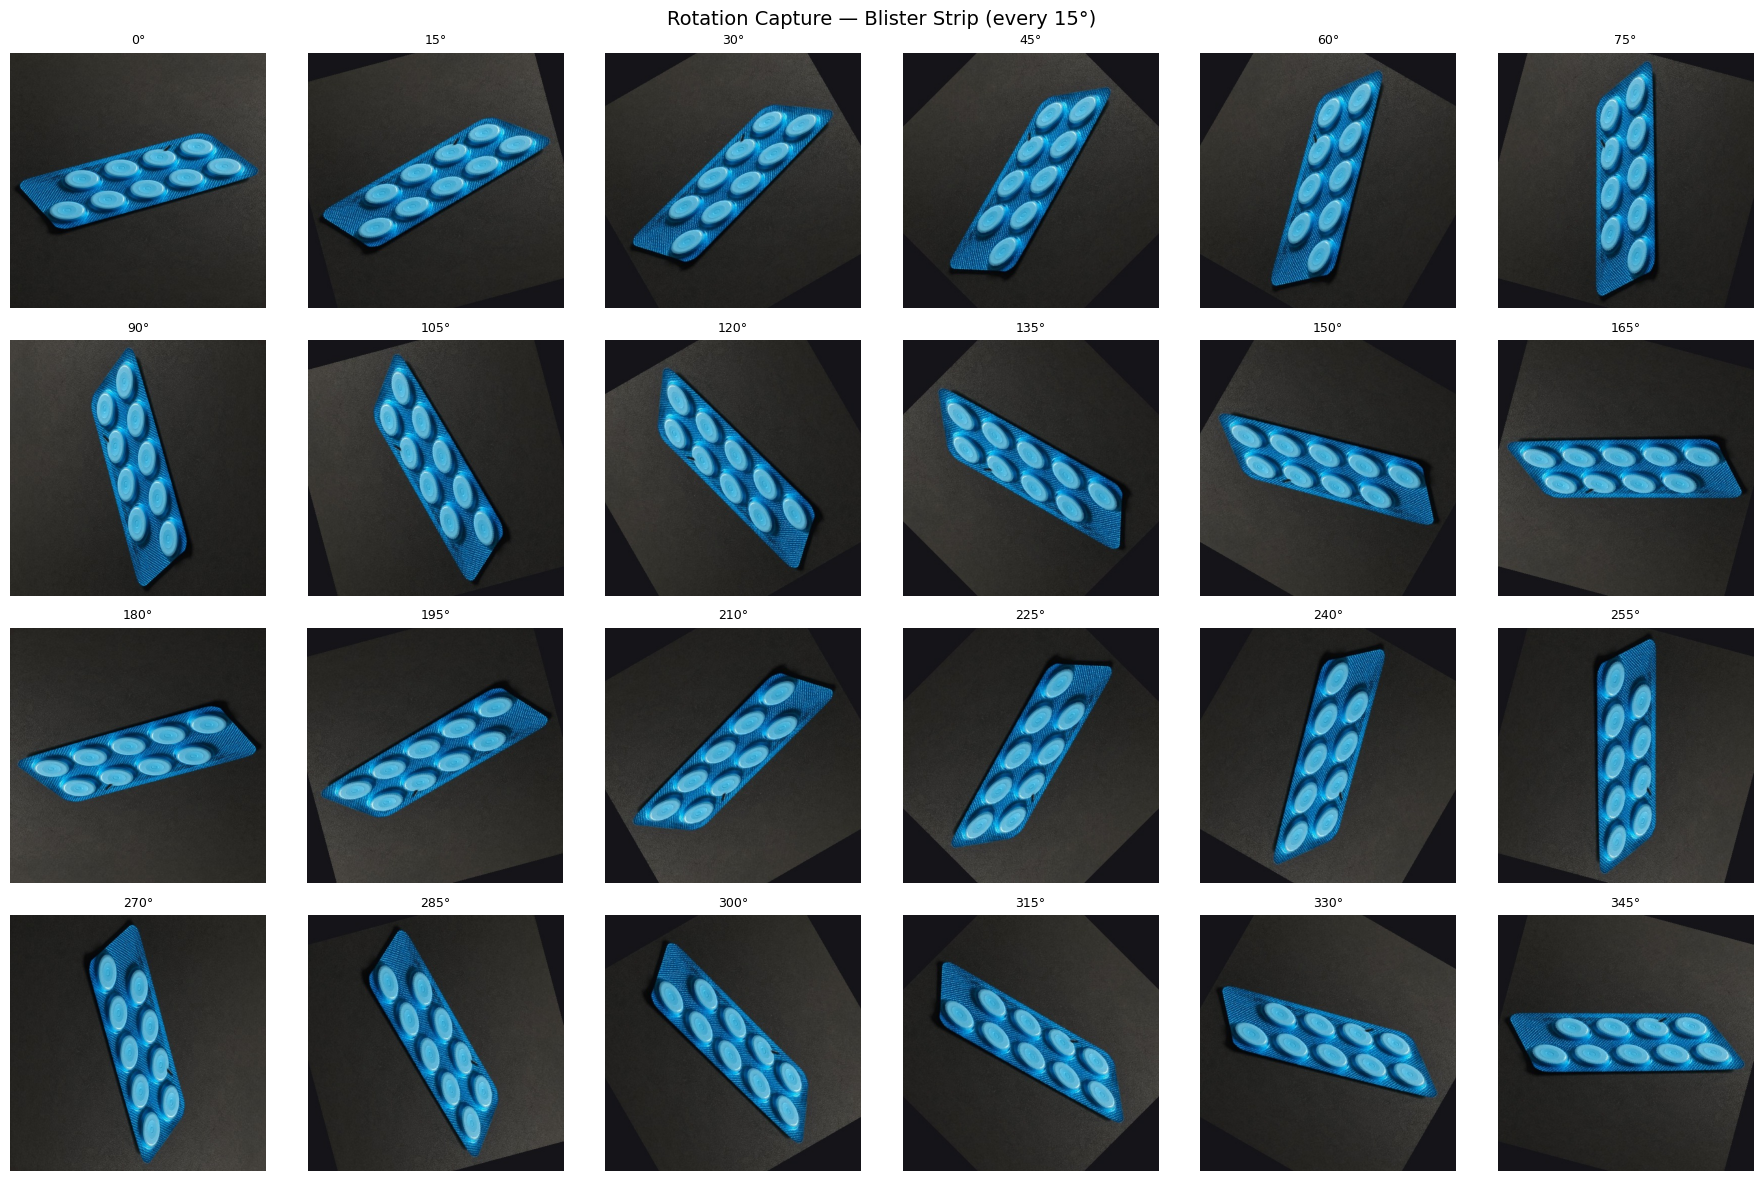

Saved 24 rotated frames to /kaggle/working/rotations/


In [8]:
# Pick one good test strip and rotate it every 15 degrees -> 24 frames
os.makedirs('/kaggle/working/rotations', exist_ok=True)
good_src = sorted(glob.glob(f'{DATA}/test/good/*.jpg'))[0]
base = Image.open(good_src).convert('RGB').resize((512,512))

angles = list(range(0, 360, 15))  # 0,15,...,345 = 24 frames
for a in angles:
    rot = base.rotate(a, expand=False, fillcolor=(20,20,25))
    rot.save(f'/kaggle/working/rotations/blister_{a:03d}.jpg', quality=92)

# Preview grid
fig, axes = plt.subplots(4, 6, figsize=(18,12))
for ax, a in zip(axes.flatten(), angles):
    ax.imshow(Image.open(f'/kaggle/working/rotations/blister_{a:03d}.jpg'))
    ax.set_title(f'{a}°', fontsize=9); ax.axis('off')
plt.suptitle('Rotation Capture — Blister Strip (every 15°)', fontsize=14)
plt.tight_layout(); plt.savefig('/kaggle/working/rotation_grid.png', dpi=120); plt.show()
print(f'Saved 24 rotated frames to /kaggle/working/rotations/')

Video saved: /kaggle/working/blister_detection.mp4


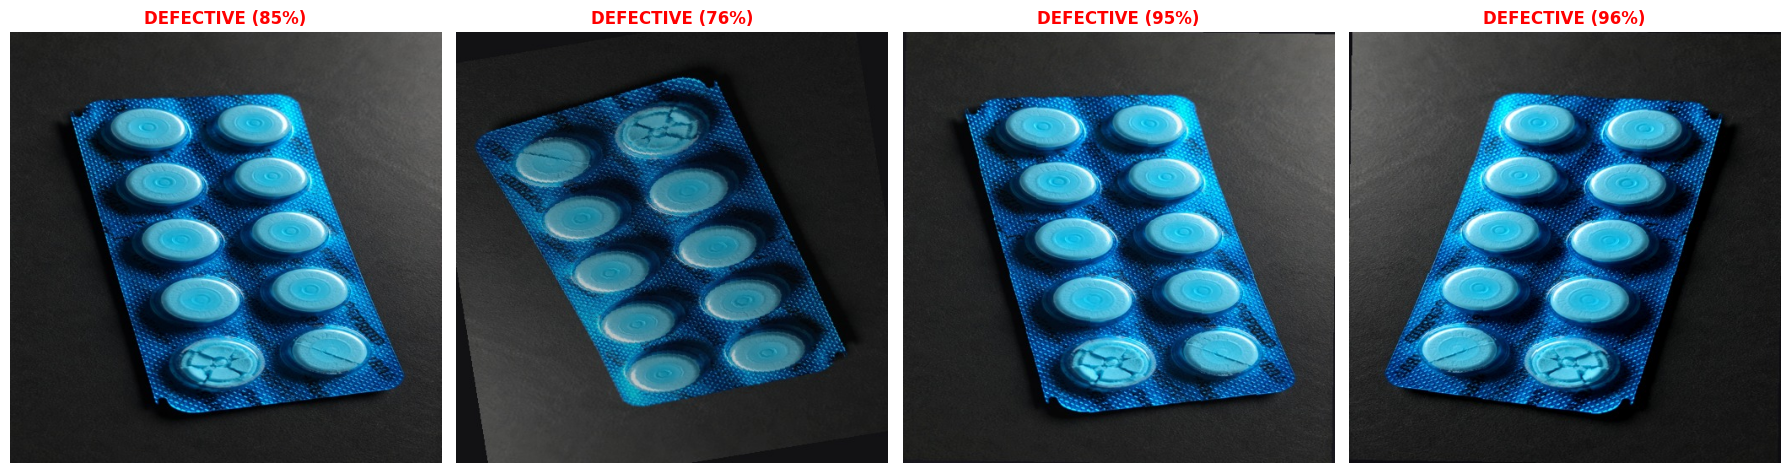

In [9]:
# Build a video from test images with live GOOD/DEFECT prediction overlaid on each frame
import cv2
out_path = '/kaggle/working/blister_detection.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
W = H = 512
writer = cv2.VideoWriter(out_path, fourcc, 1.5, (W, H))  # 1.5 fps

# Use all test images + the rotation frames as the "moving" sequence
frame_paths = sorted(glob.glob(f'{DATA}/test/defect/*.jpg'))[:15] + \
              sorted(glob.glob(f'{DATA}/test/good/*.jpg'))[:10] + \
              sorted(glob.glob('/kaggle/working/rotations/*.jpg'))

for p in frame_paths:
    img = Image.open(p).convert('RGB')
    tensor = test_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.softmax(model(tensor),1)[0,1].item()
    label = 'DEFECTIVE' if prob>0.5 else 'GOOD'
    conf = prob if prob>0.5 else 1-prob
    color = (0,0,255) if prob>0.5 else (0,180,0)  # BGR

    frame = cv2.cvtColor(np.array(img.resize((W,H))), cv2.COLOR_RGB2BGR)
    # Banner
    cv2.rectangle(frame, (0,0), (W,60), (0,0,0), -1)
    cv2.putText(frame, f'{label}  {conf:.0%}', (15,42),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, color, 3)
    # Border in class color
    cv2.rectangle(frame, (2,62), (W-2,H-2), color, 4)
    writer.write(frame)

writer.release()
print(f'Video saved: {out_path}')

# Show a few sample frames inline
fig, axes = plt.subplots(1,4, figsize=(18,5))
for ax,p in zip(axes, frame_paths[:4]):
    img=Image.open(p).convert('RGB'); t=test_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): pr=torch.softmax(model(t),1)[0,1].item()
    lbl='DEFECTIVE' if pr>0.5 else 'GOOD'; col='red' if pr>0.5 else 'green'
    ax.imshow(img); ax.set_title(f'{lbl} ({(pr if pr>0.5 else 1-pr):.0%})',color=col,fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.show()

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, confusion_matrix, classification_report

# Reload the BEST saved model cleanly
model.load_state_dict(torch.load('/kaggle/working/blister_best.pth', map_location=DEVICE, weights_only=True))
model.eval()

# Evaluate ONLY on the real test set (not rotations)
y_true, y_prob = [], []
eval_loader = DataLoader(BlisterDS(test_samples, test_tf), batch_size=16, num_workers=2)
with torch.no_grad():
    for x, y in eval_loader:
        x = x.to(DEVICE)
        p = torch.softmax(model(x), dim=1)[:, 1]
        y_true.extend(y.numpy())
        y_prob.extend(p.cpu().numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print('='*50)
print('SINGLE CLEAN EVALUATION — TEST SET')
print('='*50)
print(f'Test images: {len(y_true)}  ({sum(y_true==0)} good, {sum(y_true==1)} defect)')
print(f'Predicted good: {sum(y_pred==0)}, predicted defect: {sum(y_pred==1)}')
print()
print(classification_report(y_true, y_pred, target_names=['good','defect'], zero_division=0))
print(f'Average Precision (AP): {average_precision_score(y_true, y_prob):.4f}')
print(f'F1-Score:               {f1_score(y_true, y_pred, zero_division=0):.4f}')
print()
cm = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(f'              Pred GOOD  Pred DEFECT')
print(f'  True GOOD     {cm[0][0]:5d}      {cm[0][1]:5d}')
print(f'  True DEFECT   {cm[1][0]:5d}      {cm[1][1]:5d}')

SINGLE CLEAN EVALUATION — TEST SET
Test images: 77  (37 good, 40 defect)
Predicted good: 54, predicted defect: 23

              precision    recall  f1-score   support

        good       0.69      1.00      0.81        37
      defect       1.00      0.57      0.73        40

    accuracy                           0.78        77
   macro avg       0.84      0.79      0.77        77
weighted avg       0.85      0.78      0.77        77

Average Precision (AP): 0.8190
F1-Score:               0.7302

Confusion Matrix:
              Pred GOOD  Pred DEFECT
  True GOOD        37          0
  True DEFECT      17         23


In [11]:
import shutil
shutil.make_archive('/kaggle/working/rotations_zip','zip','/kaggle/working/rotations')
print('Deliverables in /kaggle/working/ (download from the Output panel on the right):')
for f in ['blister_pr_curve.png','blister_detection.mp4','rotation_grid.png','rotations_zip.zip','blister_best.pth']:
    p=f'/kaggle/working/{f}'
    if os.path.exists(p): print(f'  ✓ {f}  ({os.path.getsize(p)//1024} KB)')

Deliverables in /kaggle/working/ (download from the Output panel on the right):
  ✓ blister_pr_curve.png  (35 KB)
  ✓ blister_detection.mp4  (2002 KB)
  ✓ rotation_grid.png  (2704 KB)
  ✓ rotations_zip.zip  (1405 KB)
  ✓ blister_best.pth  (43740 KB)


In [12]:
from IPython.display import FileLink
FileLink('/kaggle/working/blister_best.pth')

/kaggle/working/blister_best.pth

In [13]:
torch.save(model.state_dict(), '/kaggle/working/blister_best.pth')
print('Exists now:', os.path.exists('/kaggle/working/blister_best.pth'))
print('Size:', os.path.getsize('/kaggle/working/blister_best.pth'), 'bytes')

Exists now: True
Size: 44790091 bytes


In [14]:
from IPython.display import FileLink
FileLink('/kaggle/working/blister_best.pth')

/kaggle/working/blister_best.pth

In [15]:
"""
Live Blister Strip Defect Detection — Webcam (ResNet18)
=======================================================
Corrected version:
  - DirectShow camera backend (fixes the Windows freeze)
  - Center-box classification by default (reliable; YOLO boxed random objects)
  - Prints the raw defect probability so you can see the model's actual output
  - THRESHOLD is adjustable — raise it if good strips read as defective

SETUP (laptop, one time):
    pip install torch torchvision opencv-python pillow numpy

FILES (same folder as this script):
    blister_best.pth   <- your trained model

RUN (Windows PowerShell / CMD):
    python webcam_blister_final.py

CONTROLS (click the video window first, then press):
    q = quit
    s = save screenshot
    + = raise threshold (fewer DEFECTIVE calls)
    - = lower threshold (more DEFECTIVE calls)
"""

import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np

# ---- adjustable: model says DEFECTIVE only when prob exceeds this ----
THRESHOLD = 0.85   # start high because the model over-predicts defective

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

clf = models.resnet18(weights=None)
clf.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(clf.fc.in_features, 2))
clf.load_state_dict(torch.load('blister_best.pth', map_location=DEVICE))
clf = clf.to(DEVICE).eval()
print('Classifier loaded: blister_best.pth')

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def defect_prob(roi_bgr):
    img = Image.fromarray(cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB))
    t = tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return torch.softmax(clf(t), dim=1)[0, 1].item()

# ---- DirectShow backend is the Windows freeze fix ----
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
if not cap.isOpened():
    print('Index 0 failed, trying index 1...')
    cap = cv2.VideoCapture(1, cv2.CAP_DSHOW)
if not cap.isOpened():
    print('ERROR: cannot open webcam.')
    exit()
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

print('\nWebcam started. Hold a blister strip inside the center box.')
print('q=quit  s=save  +/- = adjust threshold\n')

history = []
HISTORY_LEN = 5
shot = 0

while True:
    ret, frame = cap.read()
    if not ret:
        print('No frame.')
        break
    h, w = frame.shape[:2]

    # center square region of interest
    box = min(h, w) - 80
    x1 = (w - box) // 2
    y1 = (h - box) // 2
    x2, y2 = x1 + box, y1 + box
    region = frame[y1:y2, x1:x2]

    prob = defect_prob(region)
    print(f'defect prob: {prob:.2f}   (threshold {THRESHOLD:.2f})')

    history.append(prob)
    if len(history) > HISTORY_LEN:
        history.pop(0)
    avg = float(np.mean(history))

    if avg > THRESHOLD:
        label, conf, color = 'DEFECTIVE', avg, (0, 0, 255)
    else:
        label, conf, color = 'GOOD', 1 - avg, (0, 180, 0)

    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
    cv2.rectangle(frame, (0, 0), (w, 70), (0, 0, 0), -1)
    cv2.putText(frame, f'{label}  {conf*100:.0f}%',
                (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.3, color, 3)
    cv2.putText(frame, f'thresh {THRESHOLD:.2f}  |  q=quit s=save +/-=adjust',
                (20, h - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    cv2.imshow('Blister Detection (ResNet18)', frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('s'):
        fn = f'webcam_capture_{shot:03d}.jpg'
        cv2.imwrite(fn, frame)
        print(f'Saved {fn}')
        shot += 1
    elif key == ord('+') or key == ord('='):
        THRESHOLD = min(0.99, THRESHOLD + 0.05)
    elif key == ord('-') or key == ord('_'):
        THRESHOLD = max(0.05, THRESHOLD - 0.05)

cap.release()
cv2.destroyAllWindows()
print('Stopped.')

Device: cuda
Classifier loaded: blister_best.pth
Index 0 failed, trying index 1...
ERROR: cannot open webcam.

Webcam started. Hold a blister strip inside the center box.
q=quit  s=save  +/- = adjust threshold

No frame.


error: OpenCV(4.13.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'


In [ ]:
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    if root.endswith('train') and 'good' in dirs and 'defect' in dirs:
        print('REAL PATH:', root[:-6])

In [2]:
import os
found = False
for root, dirs, files in os.walk('/kaggle/input/'):
    if root.endswith('good') and len([f for f in os.listdir(root) if f.endswith('.jpg')])>0:
        d = root.replace('good','defect')
        print('GOOD path:', root, '->', len(os.listdir(root)), 'files')
        print('DEFECT path:', d, '->', len(os.listdir(d)) if os.path.exists(d) else 'MISSING')
        found = True
if not found:
    print('No good/ folder with images found. Listing everything under /kaggle/input/:')
    for root, dirs, files in os.walk('/kaggle/input/'):
        print(root, '->', len(files), 'files')

GOOD path: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/good -> 37 files
DEFECT path: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/val/defect -> 40
GOOD path: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/test/good -> 37 files
DEFECT path: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/test/defect -> 40
GOOD path: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/train/good -> 184 files
DEFECT path: /kaggle/input/datasets/p12alak/final-dataset-1/blister_dataset_v2/train/defect -> 192
GOOD path: /kaggle/input/datasets/p12alak/webcam-clean/webcam_data/good -> 50 files
DEFECT path: /kaggle/input/datasets/p12alak/webcam-clean/webcam_data/defect -> 50
GOOD path: /kaggle/input/datasets/p12alak/webcam-clean/webcam_data/webcam_data/good -> 50 files
DEFECT path: /kaggle/input/datasets/p12alak/webcam-clean/webcam_data/webcam_data/defect -> 50


In [ ]:
import os
for root, dirs, files in os.walk('/kaggle/input/'):
    if root.endswith('good') and 'webcam' in root.lower():
        print('GOOD PATH:', root)
        print('DEFECT PATH:', root.replace('good','defect'))
        break

In [3]:
import os, glob, random, numpy as np
import torch, torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

GOOD = '/kaggle/input/datasets/p12alak/webcam-clean/webcam_data/good'
DEFECT = '/kaggle/input/datasets/p12alak/webcam-clean/webcam_data/defect'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

good = glob.glob(f'{GOOD}/*.jpg'); defect = glob.glob(f'{DEFECT}/*.jpg')
print(f'{len(good)} good, {len(defect)} defect')   # MUST say 50 good, 50 defect

random.seed(0); random.shuffle(good); random.shuffle(defect)
def sp(l): k=max(1,int(len(l)*0.2)); return l[k:], l[:k]
gtr,gva = sp(good); dtr,dva = sp(defect)
train = [(p,0) for p in gtr]+[(p,1) for p in dtr]
val   = [(p,0) for p in gva]+[(p,1) for p in dva]
print(f'Train {len(train)}, Val {len(val)}')

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30), transforms.ColorJitter(0.25,0.25,0.15),
    transforms.RandomAffine(0, translate=(0.1,0.1), scale=(0.85,1.15)),
    transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
val_tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

class DS(Dataset):
    def __init__(s,samp,tf): s.samp,s.tf=samp,tf
    def __len__(s): return len(s.samp)
    def __getitem__(s,i): p,l=s.samp[i]; return s.tf(Image.open(p).convert('RGB')), l

tl = DataLoader(DS(train,train_tf), batch_size=16, shuffle=True, num_workers=2)
vl = DataLoader(DS(val,val_tf), batch_size=16, num_workers=2)

model = models.resnet18(weights=None)
model.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(model.fc.in_features,2))
model = model.to(DEVICE)
crit = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

best=0; EPOCHS=25
for ep in range(EPOCHS):
    model.train(); c=t=0
    for x,y in tl:
        x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad()
        o=model(x); loss=crit(o,y); loss.backward(); opt.step()
        c+=(o.argmax(1)==y).sum().item(); t+=y.size(0)
    model.eval(); vc=vt=0
    with torch.no_grad():
        for x,y in vl:
            x,y=x.to(DEVICE),y.to(DEVICE); vc+=(model(x).argmax(1)==y).sum().item(); vt+=y.size(0)
    va=100*vc/vt
    if va>=best: best=va; torch.save(model.state_dict(),'/kaggle/working/webcam_model.pth')
    print(f'Epoch {ep+1:2d}/{EPOCHS} | train {100*c/t:.0f}% | VAL {va:.0f}%')
print(f'\nBest VAL {best:.0f}% | saved /kaggle/working/webcam_model.pth')

Device: cuda
50 good, 50 defect
Train 80, Val 20
Epoch  1/25 | train 51% | VAL 50%
Epoch  2/25 | train 54% | VAL 50%
Epoch  3/25 | train 74% | VAL 50%
Epoch  4/25 | train 69% | VAL 50%
Epoch  5/25 | train 74% | VAL 50%
Epoch  6/25 | train 70% | VAL 70%
Epoch  7/25 | train 68% | VAL 75%
Epoch  8/25 | train 76% | VAL 75%
Epoch  9/25 | train 75% | VAL 75%
Epoch 10/25 | train 79% | VAL 80%
Epoch 11/25 | train 74% | VAL 75%
Epoch 12/25 | train 71% | VAL 70%
Epoch 13/25 | train 79% | VAL 55%
Epoch 14/25 | train 79% | VAL 80%
Epoch 15/25 | train 82% | VAL 90%
Epoch 16/25 | train 80% | VAL 80%
Epoch 17/25 | train 79% | VAL 85%
Epoch 18/25 | train 82% | VAL 90%
Epoch 19/25 | train 88% | VAL 65%
Epoch 20/25 | train 84% | VAL 70%
Epoch 21/25 | train 92% | VAL 100%
Epoch 22/25 | train 82% | VAL 75%
Epoch 23/25 | train 82% | VAL 80%
Epoch 24/25 | train 84% | VAL 60%
Epoch 25/25 | train 90% | VAL 75%

Best VAL 100% | saved /kaggle/working/webcam_model.pth
